# ITCHI v0.1 — Cristóbal 2020 (NA) y Odile 2014 (EP): ROCLOUD frente a radios paramétricos W06

Objetivos:

1. Leer ROCLOUD (`data/external/Rocloud/ROCLOUD_{NA,EP}.csv`) y documentar sus convenciones: radios en km, `0.0` = cuadrante sin detección, `MWS` en km h⁻¹.
2. Comparar el radio exterior W06 con ROCLOUD, para el caso y para toda la cuenca.
3. Calcular ITCHI diario (MSWEP diario + percentiles diarios, opción B) con tres radios de atribución: `rocloud`, `w06` y `rocloud_fallback_w06`, y cuantificar la diferencia en el índice.

Se ejecuta un caso por corrida: elige `CASE` en la celda de parámetros.

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats

from itchi.aggregation import compute_event_accumulated, compute_event_max
from itchi.climatology import (
    compute_standard_precipitation_climatology,
    extract_standard_percentiles,
)
from itchi.config import get_project_root, load_default_config
from itchi.constants import QUADRANTS
from itchi.geometry import build_geometry_fields
from itchi.ibtracs import (
    _decode_text_sequence,  # helper privado, solo para decodificar nombres
    get_ibtracs_storm_ids,
    ibtracs_to_track_dataframe,
    read_ibtracs_dataset,
)
from itchi.mswep import (
    extract_mswep_precipitation,
    infer_mswep_lat_lon_names,
    read_mswep_dataset,
    standardize_mswep_time,
    subset_mswep_domain,
)
from itchi.parametric_radii import (
    add_parametric_radii,
    compute_parametric_radii,
    compute_w06_wind_hazard,
    parametric_direct_fallback_km,
)
from itchi.pipeline import compute_itchi_snapshot_from_grid
from itchi.plotting import plot_itchi_field
from itchi.radii import fill_missing_quadrant_radii, resolve_direct_radius
from itchi.rocloud import (
    DEFAULT_ROCLOUD_COLUMN_MAP,
    ROCLOUD_TEXT_COLUMNS,
    standardize_rocloud_text_dataframe,
)
from itchi.tracks import DEFAULT_R34_COLUMN_MAP, filter_synoptic_times
from itchi.units import NAUTICAL_MILE_TO_KM, convert_quadrant_radii_to_km
from itchi.wind import compute_radial_wind_profile
from itchi.wind_profiles import KNOT_TO_MS, V_R5_MS, V_R34_MS, Willoughby2006Profile

## 0. Parámetros

In [2]:
ROOT = get_project_root()
CFG = load_default_config()
PR = CFG.get("parametric_radii", {})

CASES = {
    "CRISTOBAL2020": dict(name="CRISTOBAL", season=2020, basin="NA", atcf="AL032020",
                          t_check="2020-06-03 12:00"),   # primera entrada a tierra (Campeche)
    "ODILE2014": dict(name="ODILE", season=2014, basin="EP", atcf="EP152014",
                      t_check="2014-09-15 00:00"),       # cerca de la entrada a tierra (Baja California Sur)
}
CASE = "CRISTOBAL2020"                     # cambia a "ODILE2014" para el Pacífico
C = CASES[CASE]
T_CHECK = pd.Timestamp(C["t_check"])

IBTRACS_FILE = ROOT / CFG["paths"]["tracks"] / f"IBTrACS.{C['basin']}.v04r01.nc"
ROCLOUD_DIR = ROOT / "data" / "external" / "Rocloud"
ROCLOUD_FILE = ROCLOUD_DIR / f"ROCLOUD_{C['basin']}.csv"
ROCLOUD_MWS_TO_KT = 1.0 / 1.852           # MWS de ROCLOUD está en km/h (46.25 = 25 kt)

MSWEP_DAILY_DIR = Path("/mnt/d/MSWEP_V280/merged/Daily")
MSWEP_FILE_PATTERN = "{date:%Y%j}.nc"
MSWEP_DAILY_STAMP = "start"
PRECIP_VAR = CFG["precipitation"]["variable_name"]

CLIM_YEARS = (2000, 2024)
CLIM_MONTHS = tuple(range(5, 12))
PAD_DEG = 10.0
CLIM_FILE = ROOT / CFG["paths"]["climatology"] / f"mswep_daily_q_{CASE.lower()}.nc"

THRESHOLDS = {"r_outer_km": PR.get("outer_threshold_ms", 2.0), "r34_km": V_R34_MS}
RMW_UNIT = PR.get("rmw_unit", "km")
assert RMW_UNIT == "km", "rmw_km ya sale en km de ibtracs.py"
WIND_PROFILE = PR.get("wind_profile", "rankine")
RADII_PREFIX = "calib_r34_"               # radios W06 usados en ITCHI

FIG_DIR = ROOT / CFG["outputs"]["figures"] / CASE.lower()
FIG_DIR.mkdir(parents=True, exist_ok=True)
DIAG_DIR = ROOT / CFG["outputs"]["diagnostics"]
DIAG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Trayectoria IBTrACS

In [4]:
ds_ib = read_ibtracs_dataset(IBTRACS_FILE)
sids = np.asarray(get_ibtracs_storm_ids(ds_ib))
names = np.asarray(_decode_text_sequence(ds_ib["name"].values))
seasons = np.asarray(ds_ib["season"].values).astype(int)
match = sids[(names == C["name"]) & (seasons == C["season"])]
assert match.size == 1, f"coincidencias: {match}"
SID = str(match[0])

track = ibtracs_to_track_dataframe(ds_ib, SID)          # rmw_km en km
track = filter_synoptic_times(track).dropna(subset=["vmax_kt", "lat", "lon"])
track = track.reset_index(drop=True)
print(SID, C["atcf"], len(track), "registros sinópticos",
      track["time"].min(), "->", track["time"].max())

2020154N19269 AL032020 43 registros sinópticos 2020-06-01 18:00:00 -> 2020-06-12 06:00:00


## 2. ROCLOUD

El lector de `itchi.rocloud` no sirve tal cual para estos CSV: el archivo plano se confunde con el formato de bloques (la primera fila `7,6,2000,...` se interpreta como encabezado) y `read_rocloud_table` asume encabezado en los `.csv`. Aquí se lee con pandas y se estandariza con la función del paquete. Convenciones verificadas en los datos:

- `0.0` en un cuadrante significa sin detección: `Rp` es la media de los cuadrantes no nulos. Se convierte a NaN.
- `MWS` está en km h⁻¹ (`46.25` = 25 kt), aunque el paquete lo renombra a `vmax_kt`. Aquí se corrige a `vmax_kt_rocloud`.
- `-9999` es valor faltante (`CPSL`).

In [5]:
ROC_COLS = [DEFAULT_ROCLOUD_COLUMN_MAP[q] for q in QUADRANTS]


def read_rocloud_csv(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path, header=None, names=list(ROCLOUD_TEXT_COLUMNS), na_values=[-9999])
    df = standardize_rocloud_text_dataframe(raw)
    df[ROC_COLS] = df[ROC_COLS].where(df[ROC_COLS] > 0)          # 0 = sin detección
    df["vmax_kt_rocloud"] = df.pop("vmax_kt") * ROCLOUD_MWS_TO_KT  # km/h -> kt
    return df


roc_all = read_rocloud_csv(ROCLOUD_FILE)
roc = roc_all[roc_all["storm_id"] == C["atcf"]].set_index("time").sort_index()
print(f"ROCLOUD {C['basin']}: {len(roc_all)} registros; caso {C['atcf']}: {len(roc)}")
print("cuadrantes sin detección en el caso:", roc[ROC_COLS].isna().sum().to_dict())

# Coherencia de posición e intensidad con IBTrACS en tiempos comunes
chk = track.set_index("time").join(roc[["lat", "lon", "vmax_kt_rocloud"]], rsuffix="_roc", how="inner")
print("tiempos comunes:", len(chk),
      "| max |Δlat|, |Δlon| =", float((chk.lat - chk.lat_roc).abs().max()),
      float((chk.lon - chk.lon_roc).abs().max()),
      "| max |ΔVmax| (kt) =", float((chk.vmax_kt - chk.vmax_kt_rocloud).abs().max()))

ROCLOUD NA: 5255 registros; caso AL032020: 30
cuadrantes sin detección en el caso: {'rocloud_rne': 0, 'rocloud_rse': 1, 'rocloud_rsw': 3, 'rocloud_rnw': 1}
tiempos comunes: 30 | max |Δlat|, |Δlon| = 1.5258789076710855e-06 3.051757815342171e-06 | max |ΔVmax| (kt) = 0.053995680345579444


## 3. Radios paramétricos W06 del caso y comparación con ROCLOUD

In [6]:
CONFIGS = {
    "pa21": dict(use_observed_rmw=False, calibrate_to_r34=False, rmax_variant="pa21"),
    "obs_rmw": dict(use_observed_rmw=True, calibrate_to_r34=False),
    "calib_r34": dict(use_observed_rmw=True, calibrate_to_r34=True),
}
for name, kwargs in CONFIGS.items():
    track = add_parametric_radii(track, rmw_unit=RMW_UNIT, r34_unit="nm",
                                 thresholds_ms=THRESHOLDS, prefix=f"{name}_", **kwargs)

r34_cols = [DEFAULT_R34_COLUMN_MAP[q] for q in QUADRANTS]
track["r34_obs_km"] = track[r34_cols].where(track[r34_cols] > 0).mean(axis=1) * NAUTICAL_MILE_TO_KM
track = track.merge(roc[["rocloud_mean_km"] + ROC_COLS].reset_index(), on="time", how="left")

rows = []
for name in CONFIGS:
    d = track[[f"{name}_r_outer_km", "rocloud_mean_km"]].dropna()
    err = d.iloc[:, 0] - d.iloc[:, 1]
    rows.append(dict(config=name, N=len(d), bias_km=err.mean(), mae_km=err.abs().mean(),
                     pearson=d.corr().iloc[0, 1] if len(d) > 2 else np.nan))
case_metrics = pd.DataFrame(rows).set_index("config").round(2)
case_metrics

,N,bias_km,mae_km,pearson
config,,,,
pa21,30,-0.74,107.10,0.07
obs_rmw,30,107.46,161.52,-0.23
calib_r34,30,120.46,294.52,-0.22


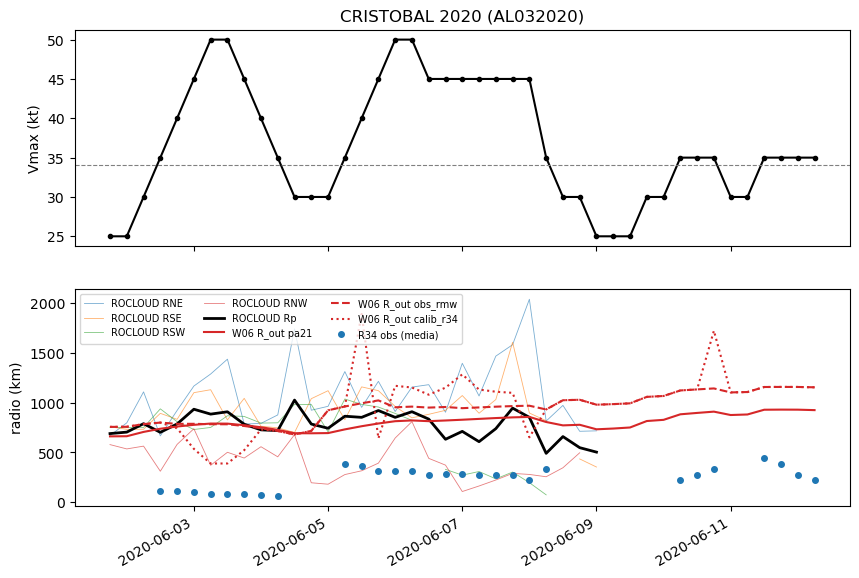

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(track["time"], track["vmax_kt"], "k-o", ms=3)
axes[0].axhline(34, color="0.5", ls="--", lw=0.8)
axes[0].set_ylabel("Vmax (kt)")
axes[0].set_title(f"{C['name']} {C['season']} ({C['atcf']})")

for col, q in zip(ROC_COLS, QUADRANTS):
    axes[1].plot(track["time"], track[col], lw=0.6, alpha=0.6, label=f"ROCLOUD {q}")
axes[1].plot(track["time"], track["rocloud_mean_km"], "k-", lw=2, label="ROCLOUD Rp")
for name, style in zip(CONFIGS, ("-", "--", ":")):
    axes[1].plot(track["time"], track[f"{name}_r_outer_km"], "C3" + style, lw=1.5,
                 label=f"W06 R_out {name}")
axes[1].plot(track["time"], track["r34_obs_km"], "C0o", ms=4, label="R34 obs (media)")
axes[1].set_ylabel("radio (km)")
axes[1].legend(ncol=3, fontsize=7)
fig.autofmt_xdate()
# fig.savefig(FIG_DIR / "radii_w06_vs_rocloud.png", dpi=150, bbox_inches="tight")

## 4. Evaluación en toda la cuenca: W06 (config. PA21) frente a ROCLOUD `Rp`

Usa solo la información de ROCLOUD (posición y `MWS`), sin IBTrACS, por lo que corresponde a la configuración `pa21` (Rmax por regresión, sin calibración a R34). La referencia es un pronóstico constante igual a la mediana de `Rp`: si W06 no mejora ese MAE, no aporta información sobre el tamaño más allá de la climatología.

In [8]:
basin_rows = []
for thr_name, thr in (("2 m/s", 2.0), ("5 kt", V_R5_MS)):
    r_w06 = compute_parametric_radii(
        roc_all["vmax_kt_rocloud"].to_numpy(), roc_all["lat"].to_numpy(),
        thresholds_ms={"r": thr}, rmax_variant="pa21",
    )["r"]
    rp = roc_all["rocloud_mean_km"].to_numpy()
    ok = np.isfinite(r_w06) & np.isfinite(rp)
    err = r_w06[ok] - rp[ok]
    basin_rows.append({
        "umbral": thr_name, "N": int(ok.sum()),
        "mediana_W06_km": np.median(r_w06[ok]), "mediana_Rp_km": np.median(rp[ok]),
        "bias_km": err.mean(), "MAE_km": np.abs(err).mean(),
        "MAE_W06_sin_sesgo_km": np.abs(err - err.mean()).mean(),
        "MAE_mediana_constante_km": np.abs(rp[ok] - np.median(rp[ok])).mean(),
        "pearson": stats.pearsonr(r_w06[ok], rp[ok])[0],
        "spearman": stats.spearmanr(r_w06[ok], rp[ok])[0],
    })
basin_metrics = pd.DataFrame(basin_rows).set_index("umbral").round(2)
basin_metrics.to_csv(DIAG_DIR / f"w06_vs_rocloud_{C['basin']}.csv")
basin_metrics

,N,mediana_W06_km,mediana_Rp_km,bias_km,MAE_km,MAE_W06_sin_sesgo_km,MAE_mediana_constante_km,pearson,spearman
umbral,,,,,,,,,
2 m/s,5255,766.81,655.71,110.27,178.09,158.24,152.51,0.14,0.13
5 kt,5255,691.06,655.71,32.99,160.07,159.11,152.51,0.14,0.13


## 5. Perfiles radiales en el tiempo de verificación

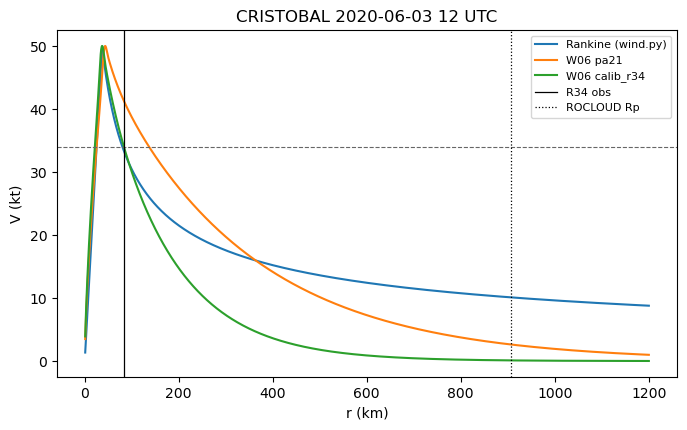

In [9]:
row = track.loc[track["time"] == T_CHECK].squeeze()
r = np.linspace(1.0, 1200.0, 2400)
vmax, lat = float(row["vmax_kt"]), float(row["lat"])
rmw = float(row["rmw_km"]) if np.isfinite(row["rmw_km"]) else float(row["obs_rmw_rmax_km"])

profiles = {
    "Rankine (wind.py)": compute_radial_wind_profile(r, vmax_kt=vmax, rmw_km=rmw),
    "W06 pa21": Willoughby2006Profile(vmax * KNOT_TO_MS, lat, rmax_variant="pa21")(r) / KNOT_TO_MS,
    "W06 calib_r34": Willoughby2006Profile(
        vmax * KNOT_TO_MS, lat, rmw, x1_km=float(row["calib_r34_x1_km"])
    )(r) / KNOT_TO_MS,
}
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, v in profiles.items():
    ax.plot(r, v, label=label)
ax.axhline(34, color="0.4", ls="--", lw=0.8)
for value, style, label in ((row["r34_obs_km"], "k-", "R34 obs"),
                            (row["rocloud_mean_km"], "k:", "ROCLOUD Rp")):
    if np.isfinite(value):
        ax.axvline(value, color=style[0], ls=style[1:], lw=0.9, label=label)
ax.set(xlabel="r (km)", ylabel="V (kt)", title=f"{C['name']} {T_CHECK:%Y-%m-%d %H} UTC")
ax.legend(fontsize=8)
fig.savefig(FIG_DIR / "radial_profiles.png", dpi=150, bbox_inches="tight")

## 6. MSWEP diario

In [10]:
def mswep_daily_path(day: pd.Timestamp) -> Path:
    return MSWEP_DAILY_DIR / MSWEP_FILE_PATTERN.format(date=day)


days = pd.date_range(track["time"].min().floor("D"), track["time"].max().floor("D"), freq="D")
bbox = dict(
    lon_min=float(track["lon"].min()) - PAD_DEG, lon_max=float(track["lon"].max()) + PAD_DEG,
    lat_min=max(float(track["lat"].min()) - PAD_DEG, -60.0),
    lat_max=min(float(track["lat"].max()) + PAD_DEG, 60.0),
)
missing = [d for d in days if not mswep_daily_path(d).exists()]
print(f"{len(days)} días; faltan {len(missing)} archivos", missing[:3])


def read_daily_precipitation(day: pd.Timestamp) -> xr.DataArray:
    file_day = day if MSWEP_DAILY_STAMP == "start" else day + pd.Timedelta(days=1)
    data = read_mswep_dataset(mswep_daily_path(file_day))
    precip = standardize_mswep_time(extract_mswep_precipitation(data, PRECIP_VAR))
    precip = subset_mswep_domain(precip, **bbox)
    return precip.isel(valid_time=0, drop=True).load()


P0 = read_daily_precipitation(days[0])
LAT_NAME, LON_NAME = infer_mswep_lat_lon_names(P0)
LON2D, LAT2D = np.meshgrid(P0[LON_NAME].values, P0[LAT_NAME].values)
print(P0.shape, P0.attrs.get("units"))

12 días; faltan 0 archivos []
(524, 335) mm d-1


## 7. Climatología diaria Q90/Q95/Q99 (se calcula una vez por caso y se guarda)

In [ ]:
clim_ds = xr.open_dataset(CLIM_FILE)
print(clim_ds)                                            # revisa nombres, dims y unidades

# Formato A: una variable con dimensión de cuantil (como produce xarray.quantile)
qdim = next((d for d in ("quantile", "percentile") if d in clim_ds.dims), None)
if qdim is not None:
    var = next(iter(clim_ds.data_vars))
    levels = np.asarray(clim_ds[qdim].values, dtype=float)
    scale = 100.0 if levels.max() <= 1.0 else 1.0         # 0.95 o 95
    clim = xr.Dataset({f"Q{int(round(level * scale))}": clim_ds[var].sel({qdim: level}, drop=True)
                       for level in levels})
# Formato B: una variable por percentil
else:
    clim = clim_ds[list(CLIM_VAR_NAMES.values())].rename(
        {v: k for k, v in CLIM_VAR_NAMES.items()})

missing = [q for q in ("Q90", "Q95", "Q99") if q not in clim]
assert not missing, f"faltan percentiles en la climatología: {missing}"

# Misma convención de coordenadas que MSWEP y misma caja del caso
clim_lat, clim_lon = infer_mswep_lat_lon_names(clim)
clim = clim.rename({clim_lat: LAT_NAME, clim_lon: LON_NAME})
clim = subset_mswep_domain(clim, **bbox)

# Misma malla de 0.1°: se exige coincidencia, no se interpola
clim = clim.reindex_like(P0, method="nearest", tolerance=1e-3)

Q90, Q95, Q99 = (np.asarray(q.values, dtype=float) for q in extract_standard_percentiles(clim))
assert Q90.shape == LON2D.shape, "la climatología y MSWEP deben compartir malla"

# Controles: cobertura, orden de los percentiles y magnitudes
finite = np.isfinite(Q90) & np.isfinite(Q95) & np.isfinite(Q99)
print(f"celdas con climatología válida: {finite.mean():.1%}")
print("Q90 <= Q95 <= Q99 en todas las celdas:",
      bool(np.all((Q90 <= Q95)[finite] & (Q95 <= Q99)[finite])))
print({k: round(float(np.nanmedian(v)), 2) for k, v in zip(("Q90", "Q95", "Q99"), (Q90, Q95, Q99))},
      "| unidades clim:", clim_ds[next(iter(clim_ds.data_vars))].attrs.get("units"),
      "| unidades MSWEP:", P0.attrs.get("units"))

## 8. Radios de atribución e ITCHI diario (opción B)

Modos de atribución:

- `rocloud`: ROCLOUD por cuadrante. Sin registro ROCLOUD válido, el snapshot se omite.
- `w06`: radio exterior W06 simétrico.
- `rocloud_fallback_w06`: ROCLOUD donde exista; W06 donde no.

Regla para cuadrantes ROCLOUD inválidos: faltante o menor que el radio directo resuelto (R34) se marca como NaN y se rellena con la media de los cuadrantes válidos (misma regla `mean_available` del pipeline); si aun así queda por debajo de R34, se iguala a R34 (región indirecta vacía en ese cuadrante). Sin esta regla, el control de calidad `R34 <= ROCLOUD` detiene la corrida.

In [ ]:
def direct_radii_km(row: pd.Series, prefix: str) -> dict:
    r34_km = convert_quadrant_radii_to_km(
        {q: row[DEFAULT_R34_COLUMN_MAP[q]] for q in QUADRANTS}, input_unit="nm")
    rmw = float(row["rmw_km"]) if np.isfinite(row["rmw_km"]) else float(row[f"{prefix}rmax_km"])
    return resolve_direct_radius(
        r34_km, vmax_kt=float(row["vmax_kt"]), rmw_km=rmw,
        fallback_radius_km=parametric_direct_fallback_km(row, f"{prefix}r34_km"),
    ).radii


def attribution_radii_km(row: pd.Series, prefix: str, mode: str):
    # Devuelve (radios por cuadrante en km o None, fuente, n cuadrantes corregidos)
    w06 = {q: float(row[f"{prefix}r_outer_km"]) for q in QUADRANTS}
    if mode == "w06":
        return w06, "w06", 0

    direct = direct_radii_km(row, prefix)
    roc_q = {q: float(row[DEFAULT_ROCLOUD_COLUMN_MAP[q]]) for q in QUADRANTS}
    invalid = [q for q in QUADRANTS if not (np.isfinite(roc_q[q]) and roc_q[q] >= direct[q])]
    if len(invalid) == len(QUADRANTS):
        return (w06, "w06_fallback", 0) if mode == "rocloud_fallback_w06" else (None, "missing", 0)

    filled = fill_missing_quadrant_radii(
        {q: (np.nan if q in invalid else roc_q[q]) for q in QUADRANTS}).radii
    final = {q: max(filled[q], direct[q]) for q in QUADRANTS}
    return final, "rocloud", len(invalid)

In [ ]:
def run_snapshot(row, precip2d, prefix, attribution, wind_profile):
    radii, source, n_fixed = attribution_radii_km(row, prefix, attribution)
    if radii is None:
        return None, source, n_fixed
    rmw = float(row["rmw_km"]) if np.isfinite(row["rmw_km"]) else float(row[f"{prefix}rmax_km"])
    wind = None
    if wind_profile == "w06":
        radius = build_geometry_fields(LON2D, LAT2D, row["lon"], row["lat"])["radius_km"]
        wind = compute_w06_wind_hazard(radius, row["vmax_kt"], row["lat"], rmw_km=rmw,
                                       x1_km=float(row[f"{prefix}x1_km"]))
    result = compute_itchi_snapshot_from_grid(
        precipitation=precip2d, q90=Q90, q95=Q95, q99=Q99,
        lon=LON2D, lat=LAT2D, center_lon=float(row["lon"]), center_lat=float(row["lat"]),
        r34_by_quadrant={q: row[DEFAULT_R34_COLUMN_MAP[q]] for q in QUADRANTS}, r34_unit="nm",
        rocloud_by_quadrant=radii, rocloud_unit="km",
        wind_hazard_normalized=wind, vmax_kt=float(row["vmax_kt"]), rmw_km=rmw,
        fallback_direct_radius_km=parametric_direct_fallback_km(row, f"{prefix}r34_km"),
        run_quality_control=True,
    )
    return result, source, n_fixed


FIELDS = ("ITCHI", "H_dir", "H_ind", "H_W", "H_P")
PRECIP_CACHE: dict = {}


def run_event(attribution: str, prefix: str = RADII_PREFIX, wind_profile: str = WIND_PROFILE):
    daily, kept_days, log = [], [], []
    for day in days:
        rows = track[track["time"].dt.floor("D") == day]
        if day not in PRECIP_CACHE:
            PRECIP_CACHE[day] = np.asarray(read_daily_precipitation(day).values, dtype=float)
        snaps = []
        for _, row in rows.iterrows():
            result, source, n_fixed = run_snapshot(row, PRECIP_CACHE[day], prefix,
                                                   attribution, wind_profile)
            log.append(dict(time=row["time"], source=source, quadrants_fixed=n_fixed))
            if result is not None:
                snaps.append(result)
        if not snaps:
            continue
        out = {k: np.nanmax(np.stack([s[k] for s in snaps]), axis=0) for k in FIELDS}
        out["M_direct"] = np.any(np.stack([s["M_direct"] for s in snaps]), axis=0)
        out["M_indirect"] = np.any(np.stack([s["M_indirect"] for s in snaps]), axis=0)
        daily.append(out)
        kept_days.append(day)

    coords = {"day": kept_days, LAT_NAME: P0[LAT_NAME].values, LON_NAME: P0[LON_NAME].values}
    dims = ("day", LAT_NAME, LON_NAME)
    ds = xr.Dataset({k: (dims, np.stack([d[k] for d in daily])) for k in daily[0]}, coords=coords)
    ds["ITCHI_max"] = compute_event_max(ds["ITCHI"], dim="day")
    ds["ITCHI_acc"] = compute_event_accumulated(ds["ITCHI"], dim="day")
    ds.attrs.update(case=CASE, sid=SID, atcf=C["atcf"], attribution=attribution,
                    radii=prefix.rstrip("_"), wind_profile=wind_profile,
                    precipitation="MSWEP daily, option B")
    return ds, pd.DataFrame(log)


events, logs = {}, {}
for mode in ("rocloud", "w06", "rocloud_fallback_w06"):
    events[mode], logs[mode] = run_event(mode)
    print(mode, logs[mode]["source"].value_counts().to_dict(),
          "| cuadrantes corregidos:", int(logs[mode]["quadrants_fixed"].sum()))

## 9. Mapas: índice por radio de atribución y diferencias respecto a ROCLOUD

In [ ]:
def map_axes(n: int, figsize=(16, 4.5)):
    fig, axes = plt.subplots(1, n, figsize=figsize, subplot_kw={"projection": ccrs.PlateCarree()})
    for ax in np.atleast_1d(axes):
        ax.coastlines(lw=0.6)
        ax.plot(track["lon"], track["lat"], "k.-", lw=0.8, ms=3, transform=ccrs.PlateCarree())
    return fig, np.atleast_1d(axes)


fig, axes = map_axes(3)
for ax, (mode, ev) in zip(axes, events.items()):
    plot_itchi_field(ev["ITCHI_max"].values, ax, lon=LON2D, lat=LAT2D,
                     crs=ccrs.PlateCarree(), colorbar_label="ITCHI_max")
    ax.set_title(f"ITCHI_max — {mode}", fontsize=10)
fig.savefig(FIG_DIR / "itchi_max_by_attribution.png", dpi=150, bbox_inches="tight")

ref = events["rocloud"]["ITCHI_max"]
fig, axes = map_axes(2, figsize=(11, 4.5))
for ax, mode in zip(axes, ("w06", "rocloud_fallback_w06")):
    diff = events[mode]["ITCHI_max"] - ref
    m = ax.pcolormesh(LON2D, LAT2D, diff.values, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
                      transform=ccrs.PlateCarree())
    fig.colorbar(m, ax=ax, shrink=0.8)
    ax.set_title(f"ΔITCHI_max ({mode} − rocloud)", fontsize=10)
fig.savefig(FIG_DIR / "itchi_max_diff_vs_rocloud.png", dpi=150, bbox_inches="tight")

## 10. Resumen del caso y comparación entre casos

In [ ]:
def event_summary(ev: xr.Dataset, reference: xr.Dataset) -> dict:
    spatial = (LAT_NAME, LON_NAME)
    diff = ev["ITCHI_max"] - reference["ITCHI_max"]
    return {
        "dias": int(ev.sizes["day"]),
        "celdas_ITCHI_max>0.5": int((ev["ITCHI_max"] > 0.5).sum()),
        "celdas_indirectas_evento": int(ev["M_indirect"].any("day").sum()),
        "media_ITCHI_max(>0)": float(ev["ITCHI_max"].where(ev["ITCHI_max"] > 0).mean()),
        "ΔITCHI_max_medio_vs_rocloud": float(diff.mean()),
        "frac_celdas_|Δ|>0.1_vs_rocloud": float((abs(diff) > 0.1).mean()),
    }


summary = pd.DataFrame(
    {mode: event_summary(ev, events["rocloud"]) for mode, ev in events.items()}
).T
summary.insert(0, "case", CASE)
summary.to_csv(DIAG_DIR / f"itchi_attribution_summary_{CASE.lower()}.csv")
display(summary.round(3))

out_dir = ROOT / CFG["outputs"]["event_products"]
out_dir.mkdir(parents=True, exist_ok=True)
for mode, ev in events.items():
    ev.to_netcdf(out_dir / f"itchi_{CASE.lower()}_{mode}_daily_optionB.nc")

In [ ]:
# Tras correr ambos casos: tabla conjunta
paths = sorted(DIAG_DIR.glob("itchi_attribution_summary_*.csv"))
pd.concat([pd.read_csv(p, index_col=0) for p in paths]).round(3) if paths else None